In [1]:
from rnd_spectra.bumps import Bumps
from rnd_spectra.ontheflydataset import OnTheFlyDataset, STFT, ISTFT
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
sns.set_theme(style="ticks",palette='tab10',rc={'axes.labelsize':14})
from torch.utils.data import DataLoader
from tld.configs import ModelConfig, TrainConfig, SpectralDataConfig, DenoiserConfig
from tld.diffusion import DiffusionGenerator
from tld.train import main
from dataclasses import asdict
from einops import rearrange
stft = STFT()
istft = ISTFT(mean=torch.Tensor([1.9e-02, -1.4e-06]), std=torch.Tensor([1.8, 0.16]))
stft_G=STFT(hop_length=1)
istft_G = ISTFT(hop_length=1,length=99,mean=torch.Tensor([2.59e-02, -1.07e-05]), std = torch.Tensor([1.4, 0.338]))

In [5]:
hparams = {
    'omega_domain': (0, 50.0),
    'num_bumps_range': (1,4), 
    'bump_widths_fraction_range': (0.03, 0.45), 
    'bump_centers_fraction_range': (0.0, 0.6)
}
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)

In [3]:
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9)
dataloader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=0)

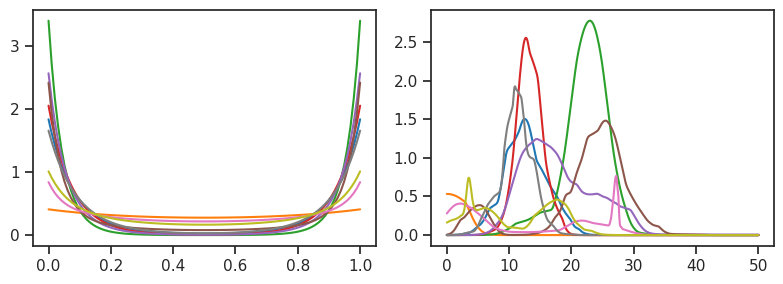

In [4]:
tau = dataloader.dataset.laplace.tau
omega = dataloader.dataset.laplace.omega
palette = ['C' + str(x) for x in range(250000)]
n_ex = 9
for C, G in dataloader:
    fig,axs = plt.subplots(1,2,figsize=(8,3))
    for j in range(n_ex):
        axs[0].plot(tau,G[j].cpu().detach().numpy().flatten(), color=palette[j])   
        axs[1].plot(omega,C[j].cpu().detach().numpy().flatten(), color=palette[j])
    plt.tight_layout()
    plt.show()

In [ ]:
# dataset = OnTheFlyDataset(bumps=bumps,dataset_size=10000,use_stft=True)
# dataloader = DataLoader(dataset, batch_size=10000, shuffle=False,num_workers=0)

In [ ]:
# for CC, GG in dataloader:
#     print(CC.mean((0,2,3)),GG.mean((0,2,3)))
#     print(CC.std((0,2,3)),GG.std((0,2,3)))

tensor([ 1.9429e-02, -1.4869e-06]) tensor([ 2.5931e-02, -1.0750e-05])
tensor([1.8042, 0.1576]) tensor([1.4023, 0.3386])


In [ ]:
# mean_CC=torch.Tensor([1.9e-02, -1.4e-06])
# mean_GG=torch.Tensor([2.59e-02, -1.07e-05])
# std_CC=torch.Tensor([1.8, 0.16])
# std_GG=torch.Tensor([1.4, 0.338])
# for CC, GG in dataloader:
#     CC = (CC-mean_CC[None, :, None, None])/std_CC[None, :, None, None]
#     GG = (GG-mean_GG[None, :, None, None])/std_GG[None, :, None, None]
#     print((CC).mean((0,2,3)),(GG).mean((0,2,3)))
#     print(CC.std((0,2,3)),GG.std((0,2,3)))

tensor([ 2.3801e-04, -9.5375e-08]) tensor([ 2.3072e-05, -1.0602e-07])
tensor([0.9929, 0.9582]) tensor([1.0012, 0.9990])


In [6]:
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9,use_stft=True)
dataloader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=0)

In [7]:
for CC, GG in dataloader:
    print(CC.shape,GG.shape)

torch.Size([9, 2, 46, 114]) torch.Size([9, 2, 46, 100])


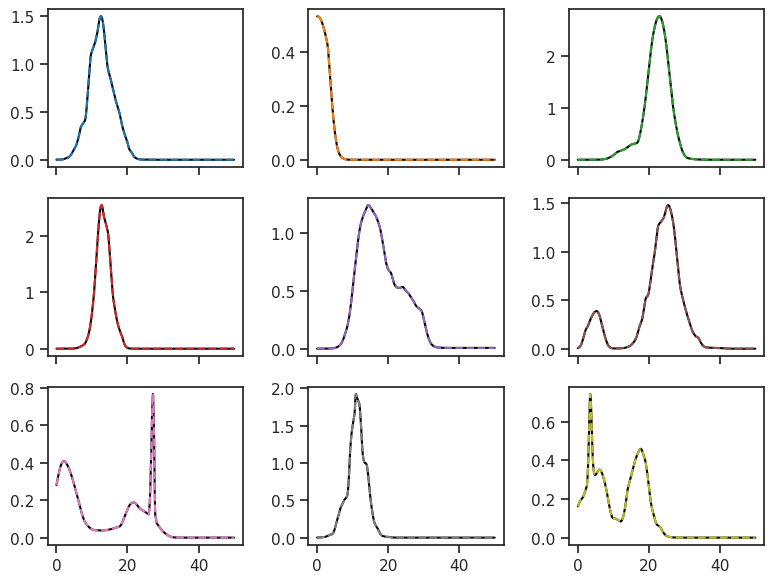

In [8]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
# C_stft = istft(stft(C.squeeze(1)))
C_stft = istft(CC)
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C[j].view(1024).cpu().detach().numpy(), color='k')
    ax.plot(omega,C_stft[j].view(1024).cpu().detach().numpy(),'--', color=palette[j])
plt.tight_layout()
plt.show()

In [9]:
Sxx = torch.view_as_complex(rearrange(CC,'b z f t -> b f t z').contiguous()).abs()
Sxx.shape

torch.Size([9, 46, 114])

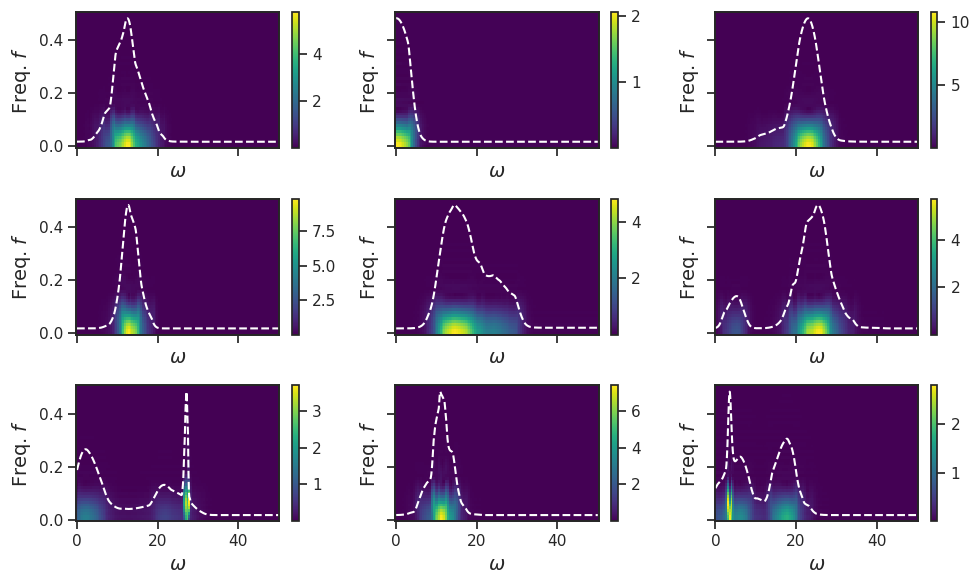

In [13]:
fig,axs = plt.subplots(3,3,figsize=(10,6),sharex=True,sharey=True)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.set(xlabel=f"$\omega$", ylabel=f"Freq. $f$")
    im=ax.pcolormesh(np.linspace(0,omega[-1],Sxx.size(-1)),torch.fft.rfftfreq(90,1).numpy(),Sxx[j],cmap='viridis')
    # im=ax.pcolormesh(np.linspace(0,omega[-1],Sxx.size(-1)),torch.fft.rfftfreq(90,1).numpy(),CC[j,0,:,:],cmap='viridis')
    fig.colorbar(im)
    ax2 = ax.twinx()
    ax2.plot(omega,istft(CC)[j].view(1024).cpu().detach().numpy(),'--', color='white')
    ax2.set_yticks(ticks=[],labels=None)
    # ax.plot(omega, torch.fft.rfftfreq(28,1).numpy(), 'r--', alpha=.5, label='$f_i(t)$')
    #,label="magnitude")
plt.tight_layout()
plt.show()

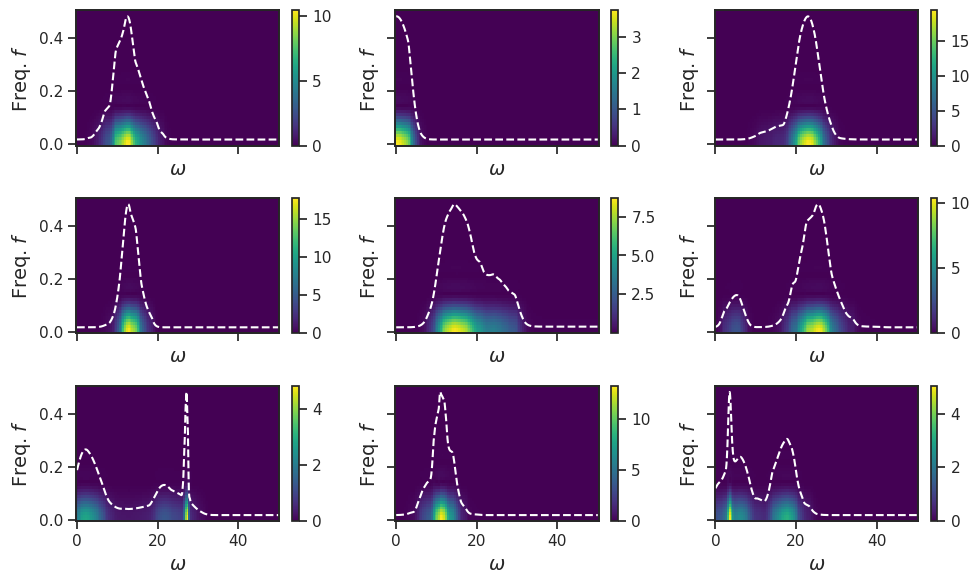

In [12]:
fig,axs = plt.subplots(3,3,figsize=(10,6),sharex=True,sharey=True)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.set(xlabel=f"$\omega$", ylabel=f"Freq. $f$")
    im=ax.pcolormesh(np.linspace(0,omega[-1],Sxx.size(-1)),torch.fft.rfftfreq(90,1).numpy(),Sxx[j],cmap='viridis')
    # im=ax.pcolormesh(np.linspace(0,omega[-1],Sxx.size(-1)),torch.fft.rfftfreq(90,1).numpy(),CC[j,0,:,:],cmap='viridis')
    fig.colorbar(im)
    ax2 = ax.twinx()
    ax2.plot(omega,istft(CC)[j].view(1024).cpu().detach().numpy(),'--', color='white')
    ax2.set_yticks(ticks=[],labels=None)
    # ax.plot(omega, torch.fft.rfftfreq(28,1).numpy(), 'r--', alpha=.5, label='$f_i(t)$')
    #,label="magnitude")
plt.tight_layout()
plt.show()

In [14]:
Sxx = torch.view_as_complex(rearrange(GG,'b z f t -> b f t z').contiguous()).abs()
Sxx.shape

torch.Size([9, 46, 100])

## With Normalization per Channel

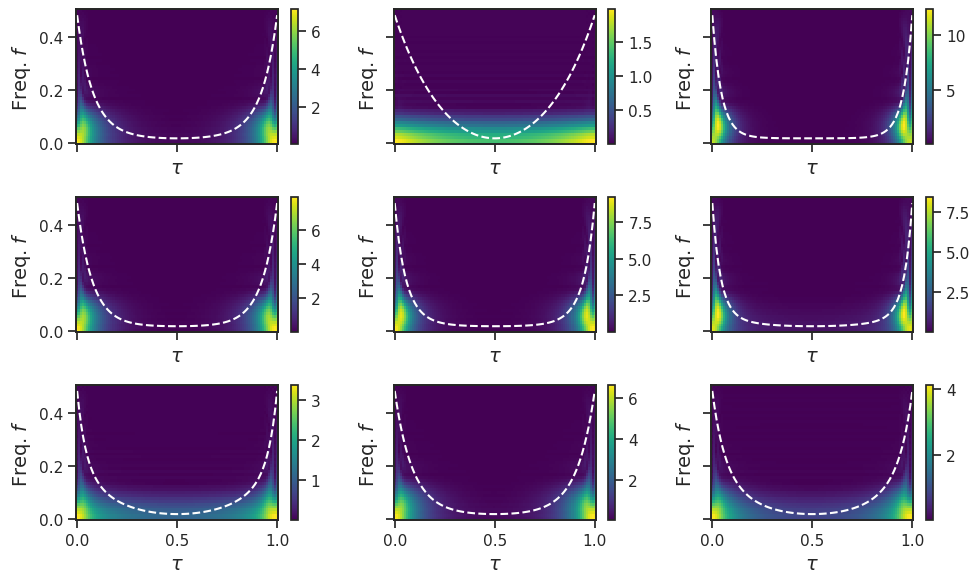

In [15]:
fig,axs = plt.subplots(3,3,figsize=(10,6),sharex=True,sharey=True)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.set(xlabel=r"$\tau$", ylabel=f"Freq. $f$")
    im=ax.pcolormesh(np.linspace(0,tau[-1],100),torch.fft.rfftfreq(90,1).numpy(),Sxx[j],cmap='viridis')
    # im=ax.pcolormesh(np.linspace(0,tau[-1],100),torch.fft.rfftfreq(90,1).numpy(),GG[j,1,:,:],cmap='viridis')
    fig.colorbar(im)
    ax2 = ax.twinx()
    ax2.plot(tau,istft_G(GG)[j].view(99).cpu().detach().numpy(),'--', color='white')
    ax2.set_yticks(ticks=[],labels=None)
    # ax.plot(omega, torch.fft.rfftfreq(28,1).numpy(), 'r--', alpha=.5, label='$f_i(t)$')
    #,label="magnitude")
plt.tight_layout()
plt.show()

## W/O Normalization

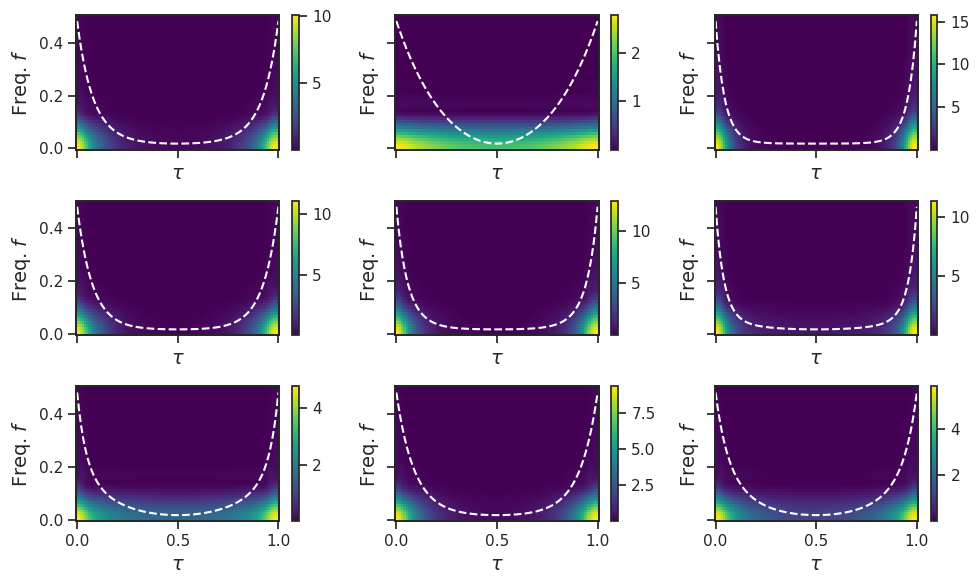

In [16]:
fig,axs = plt.subplots(3,3,figsize=(10,6),sharex=True,sharey=True)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.set(xlabel=r"$\tau$", ylabel=f"Freq. $f$")
    im=ax.pcolormesh(np.linspace(0,tau[-1],100),torch.fft.rfftfreq(90,1).numpy(),Sxx[j],cmap='viridis')
    # im=ax.pcolormesh(np.linspace(0,tau[-1],100),torch.fft.rfftfreq(90,1).numpy(),GG[j,1,:,:],cmap='viridis')
    fig.colorbar(im)
    ax2 = ax.twinx()
    ax2.plot(tau,istft_G(GG)[j].view(99).cpu().detach().numpy(),'--', color='white')
    ax2.set_yticks(ticks=[],labels=None)
    # ax.plot(omega, torch.fft.rfftfreq(28,1).numpy(), 'r--', alpha=.5, label='$f_i(t)$')
    #,label="magnitude")
plt.tight_layout()
plt.show()

# Training

In [16]:
model_cfg = ModelConfig(
    data_config=SpectralDataConfig(omega_domain=(0,50),num_bumps_range=(1,4),bump_widths_fraction_range=(0.03, 0.45)),
    denoiser_config=DenoiserConfig(),
    train_config=TrainConfig(
        compile=False, batch_size=25,n_epoch=200,
        use_wandb=True,save_model=True,
        model_name='STFT_norm_2D',
        # run_id='t4vt1bz2',
        # from_scratch=False
        )
    )
model = main(model_cfg,use_stft=True)

Creating training loader:
model prep


wandb: Currently logged in as: sagimeir (sagimeir-tel-aviv-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/home/sagi/anaconda3/lib/python3.11/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/home/sagi/anaconda3/lib/python3.11/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


The model has 11936696 parameters


100%|██████████| 800/800 [05:04<00:00,  2.63it/s]


epoch: 1 | train_loss: 0.933820449942723


...

100%|██████████| 800/800 [04:59<00:00,  2.67it/s]


epoch: 199 | train_loss: 0.006431657756620552


100%|██████████| 800/800 [05:00<00:00,  2.67it/s]

epoch: 200 | train_loss: 0.006440632114536129


train_loss,█▂▃▃▂▂▂▂▂▁▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁
train_loss,0.00644


In [ ]:
# model_cfg = ModelConfig(
#     data_config=SpectralDataConfig(omega_domain=(0,50),num_bumps_range=(1,4),bump_widths_fraction_range=(0.03, 0.45)),
#     denoiser_config=DenoiserConfig(),
#     train_config=TrainConfig(compile=False, batch_size=5,n_epoch=2,use_wandb=True,save_model=True,model_name='STFT_norm_2D')
#     )
# from tld.denoiser import Denoiser
# model = Denoiser(**asdict(model_cfg.denoiser_config))
# model.load_state_dict(torch.load('STFT_norm_2D',map_location=torch.device('cuda'))["model_ema"])

<All keys matched successfully>

In [17]:
hparams = asdict(model_cfg.data_config)
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9)
test_loader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=4) # Note: num_workers>0 to prevent the loader to create new data
for C_test, G_test in test_loader:
    print(C_test.size(),G_test.size())

torch.Size([9, 1, 1024]) torch.Size([9, 1, 99])


In [19]:
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
istft = istft.to('cuda')
istft.window=istft.window.to('cuda')
istft.std = istft.std.to('cuda')
istft.mean = istft.mean.to('cuda')
C_preds_list = [istft(diffuser.generate(
        labels= stft_G(G_test.squeeze(1)).to('cuda'),
        num_specs=9,
        class_guidance=1,
        seed=i,
        n_iter=2,
        exponent=1,
        x_points=model_cfg.denoiser_config.x_points,
        freq_x_points = model_cfg.denoiser_config.freq_x_points,
        use_ddpm_plus=True
    )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list)
C_preds_mean = C_preds_array.mean(0)
C_preds_std = C_preds_array.std(0)

100%|██████████| 1/1 [00:00<00:00, 262.59it/s]


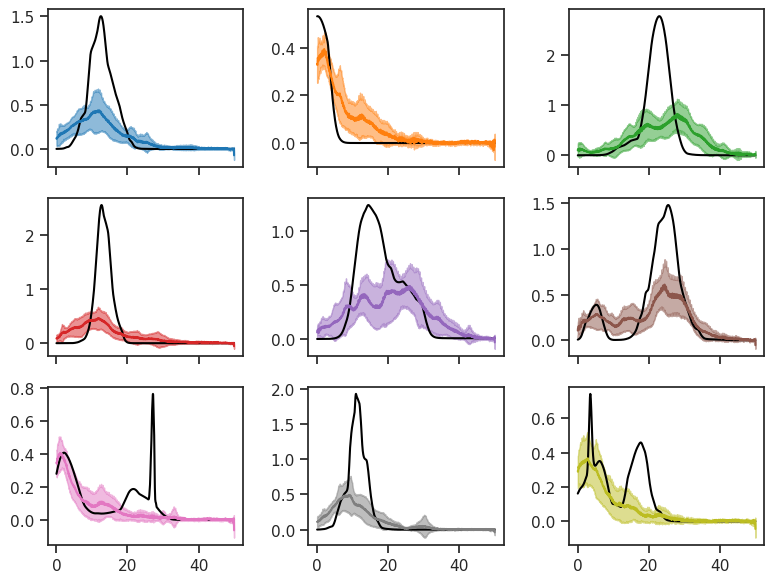

In [20]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    ax.plot(omega,C_preds_mean[j], color=palette[j])
    ax.fill_between(omega,C_preds_mean[j]-C_preds_std[j],C_preds_mean[j]+C_preds_std[j],color=palette[j],alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# #params
# kB = 3.1668114E-6  # in Hartree/K
# c = 2.99792458E10  # speed of light in cm/s
# s_in_t_au = 2.4188843265857E-17  # 1 time a.u. in s

# T = 14.0  # in K

# b = 1 / (kB * T)
# print('beta is ' + str(b))


# # rabani input:
# Nbeads = 219
# Natoms = 180
# tau = test_loader.dataset.laplace.tau
# # omega_dummy = np.linspace(omega_range[0], omega_range[1], Ng_w)

# G_rabani = np.load('data/barak/G_Rabani_' + str(T) + 'K_' + str(Natoms) + 'p.npy')
# tau_PIMD = G_rabani[0]
# G_rabani = G_rabani[1]

# # adds points to G
# G_rabani_interp = np.interp(tau, tau_PIMD, G_rabani)
# Norm_rabani = np.trapz(G_rabani_interp,tau)*np.pi
# G_rabani_interp = G_rabani_interp / Norm_rabani

# G_anal_tensor = torch.Tensor(G_rabani_interp)

# # rabani output:
# import pandas as pd
# rabani_data = pd.read_csv("data/Rabani_D_w_14K.csv", sep=",", header=None)
# rabani_data_w, rabani_data_D = rabani_data[0].values,rabani_data[1].values
# rabani_data_w *= ( 2 * np.pi * c * s_in_t_au * b ) # now omega unitless



# # # PIMD with I-pi input:
# Nbeads = 50
# df=pd.read_csv('/home/sagi/Desktop/parahydrogen/pH2_for_Amit/G_14K_50beads_180p_ipi_sym.csv')
# _, G_rabani = df['tau'].values,df['G'].values

# # # interpolate - adding points to G
# tau_PIMD = np.linspace(0,1,Nbeads+1)
# G_rabani_interp_2 = np.interp(tau, tau_PIMD, G_rabani)
# Correct_norm = np.trapz(G_rabani_interp_2,tau)*np.pi
# G_rabani_interp_2 = G_rabani_interp_2 / Correct_norm 

# G_anal_tensor_2 = torch.Tensor(G_rabani_interp_2)

beta is 22555.360078775586


In [ ]:
# diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
# istft.window=istft.window.to('cuda')
# C_preds_list_rabani = [istft(diffuser.generate(
#         labels= stft_G(G_anal_tensor.view(1,-1)).to('cuda').unsqueeze(0),
#         num_specs=1,
#         class_guidance=1.,
#         seed=i,
#         n_iter=2,
#         exponent=1,
#         x_points=514,
#         use_ddpm_plus=True
#     )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
# C_preds_array=np.array(C_preds_list_rabani)
# C_preds_mean_rabani = C_preds_array.mean(0)
# C_preds_std_rabani = C_preds_array.std(0)

100%|██████████| 1/1 [00:00<00:00, 277.84it/s]


In [ ]:
# diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
# istft.window=istft.window.to('cuda')
# C_preds_list_rabani = [istft(diffuser.generate(
#         labels= stft_G(G_anal_tensor_2.view(1,-1)).to('cuda').unsqueeze(0),
#         num_specs=1,
#         class_guidance=1.,
#         seed=i,
#         n_iter=2,
#         exponent=1,
#         x_points=514,
#         use_ddpm_plus=True
#     )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
# C_preds_array=np.array(C_preds_list_rabani)
# C_preds_mean_rabani_2 = C_preds_array.mean(0)
# C_preds_std_rabani_2 = C_preds_array.std(0)

100%|██████████| 1/1 [00:00<00:00, 257.16it/s]


In [ ]:
# mass=2.01588 # gram/mol
# hbar = 1.054571817 * 1E-34 # J * sec = kg * m^2 /sec
# hbar *= 1E+20 # kg * angstrom^2 /sec
# hbar *= 1E-12 # kg * angstrom^2 /ps
# mass /= (1000 * 6.02214076 * 1E+23) # kg
# renorm_factor = hbar*3*np.pi/mass

In [21]:
# fig,ax = plt.subplots(figsize=(4,3))
# ax.plot(omega,renorm_factor*C_preds_mean_rabani[0],label='NN (Ref input)',color='tab:blue')
# ax.fill_between(omega,renorm_factor*(C_preds_mean_rabani[0]-C_preds_std_rabani[0]),renorm_factor*(C_preds_mean_rabani[0]+C_preds_std_rabani[0]),color='tab:blue',alpha=0.5)
# print(renorm_factor*C_preds_mean_rabani[0][0]/6)
# ax.plot(omega,renorm_factor*C_preds_mean_rabani_2[0],color='tab:green',label='NN (PIMD)')
# ax.fill_between(omega,renorm_factor*(C_preds_mean_rabani_2[0]-C_preds_std_rabani_2[0]),renorm_factor*(C_preds_mean_rabani_2[0]+C_preds_std_rabani_2[0]),color='tab:green',alpha=0.5)
# print(renorm_factor*C_preds_mean_rabani_2[0][0]/6)
# ax.plot(rabani_data_w,rabani_data_D*6,'--',color='orange',label='Max Entropy')
# print(rabani_data_D[0])
# ax.legend()

In [22]:
# velFT = np.loadtxt('/home/sagi/Desktop/water/1bead/nve1/nve_facf.data', usecols=(0,1))
# velFT = velFT[velFT[:,0] * 219474<=8000]
# water_data_w, water_nve_D = velFT[:,0]* 219474 * ( 2 * np.pi * c * s_in_t_au /kB/300 ), velFT[:,1]
# norm_water_nve_D=np.trapz(y=water_nve_D,x=water_data_w)
# water_nve_D/=norm_water_nve_D
# water_nve_D *= (water_data_w + 1E-30) / (1-np.exp(-water_data_w) + 1E-30)


# Nbeads = 32
# df=pd.read_csv('/home/sagi/Desktop/water/G_300K_32beads_sym.csv')
# _, G_water = df['tau'].values,df['G'].values

# G_water_interp = np.interp(tau, np.linspace(0,1,Nbeads+1), G_water)
# Norm_water = np.trapz(G_water_interp,tau)*np.pi
# G_water_interp = G_water_interp / Norm_water
# G_water_tensor = torch.Tensor(G_water_interp)

# K = ( np.exp(- water_data_w * tau[:,None]) + np.exp(water_data_w * (tau - 1)[:,None]) )/2/np.pi
# G_water_interp2 = np.trapz(y=K*water_nve_D,x=water_data_w)
# print(np.trapz(y=G_water_interp2,x=tau)*np.pi)
# G_water_tensor2 = torch.Tensor(G_water_interp2)

In [118]:
# plt.plot(G_water_interp)
# plt.plot(G_water_interp2)

In [23]:
# diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
# C_preds_list_water = [istft(diffuser.generate(
#         labels= stft_G(G_water_tensor.view(1,-1)).to('cuda').unsqueeze(0),
#         num_specs=1,
#         class_guidance=1.,
#         seed=i,
#         n_iter=40,
#         exponent=1,
#         x_points=514,
#         use_ddpm_plus=True
#     )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
# C_preds_array=np.array(C_preds_list_water)
# C_preds_mean_water = C_preds_array.mean(0)
# C_preds_std_water = C_preds_array.std(0)

In [ ]:
# diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
# C_preds_list_water = [istft(diffuser.generate(
#         labels= stft_G(G_water_tensor2.view(1,-1)).to('cuda').unsqueeze(0),
#         num_specs=1,
#         class_guidance=1.,
#         seed=i,
#         n_iter=40,
#         exponent=1,
#         x_points=514,
#         use_ddpm_plus=True
#     )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
# C_preds_array=np.array(C_preds_list_water)
# C_preds_mean_water2 = C_preds_array.mean(0)
# C_preds_std_water2 = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 255.41it/s]


In [24]:
# fig,ax = plt.subplots(figsize=(4,3))
# ax.plot(omega,C_preds_mean_water[0],label='NN (PIMD)',color='tab:green')
# ax.fill_between(omega,(C_preds_mean_water[0]-C_preds_std_water[0]),(C_preds_mean_water[0]+C_preds_std_water[0]),color='tab:green',alpha=0.5)
# ax.plot(omega,C_preds_mean_water2[0],label='NN (nve)',color='tab:blue')
# ax.fill_between(omega,(C_preds_mean_water2[0]-C_preds_std_water2[0]),(C_preds_mean_water2[0]+C_preds_std_water2[0]),color='tab:blue',alpha=0.5)

# ax.plot(water_data_w,water_nve_D,color='tab:orange',label='NVE')
# ax.legend()